In [1]:
# {"AGG": "Investment-Grade Bonds",            # iShares Core U.S. Aggregate Bond ETF # LQD: iShares iBoxx $ Investment Grade Corporate Bond ETF
#  "IGOV": "International Sovereign Bonds",
#  "HYG": "High-Yield Bonds",
#  "IVV": "U.S. Equities",
#  "XEM": "Emerging Market Equities",          # iShares MSCI Emerging Markets Index ETF
#  "ACWX" "International Equities",            # iShares MSCI ACWI ex U.S. ETF
#  "IYR": "Real Estate"                        # iShares U.S. Real Estate ETF
#  "GSG": "Commodities"                        # iShares S&P GSCI Commodity-Indexed Trust
#  } 

from datetime import datetime
# S&P and Dow Jones Tickers
sp_dj_asset_tickers = {
    "SPY": "U.S. Equities",                     # SPDR S&P 500 ETF Trust                     
    "SPDW": "International Equities",           # SPDR Portfolio Developed World ex-US ETF
    "SPEM": "Emerging Market Equities",         # SPDR Portfolio Emerging Markets ETF
    "RWX": "Real Estate",                       # SPDR Dow Jones International Real Estate ETF (RWX)
    "^SPGSCI": "Commodities",                     # Dow Jones Commodity Index
    "LQD": "Investment-Grade Bonds",            # S&P 500 Bond Index
    "SPHY": "High-Yield Bonds",                 # SPDR Portfolio High Yield Bond ETF
    "BWX": "International Sovereign Bonds"      # SPDR Bloomberg International Treasury Bond ETF
}


trading_days_in_year = 252
# Define the start and end dates for fetching the data
start_date = '1990-01-01'
end_date = datetime.today().strftime("%Y-%m-%d")

In [2]:
!pip install pandas yfinance matplotlib seaborn

In [3]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

returns_df = pd.DataFrame()

# Fetch daily returns for each ticker
for ticker, asset_class in sp_dj_asset_tickers.items():
    try:
        # Fetch historical data for the ticker
        data = yf.download(ticker)
        
        # Check if the data is empty
        if data.empty:
            print(f"No data found for ticker: {ticker}")
            continue
        
        # Calculate daily returns
        data['Daily Return'] = data['Adj Close'].pct_change()
        
        # Add the daily returns to the returns DataFrame
        data = data[['Daily Return']].rename(columns={'Daily Return': asset_class})
        if returns_df.empty:
            returns_df = data
        else:
            returns_df = returns_df.join(data, how='outer')
    except Exception as e:
        print(f"Failed for ticker: {ticker}")
        print(e)
        
# Drop the first row with NaN values
returns_df = returns_df.iloc[1:]
returns_df.to_csv("../data/historical-class-returns.csv")
# Display the first few rows of the returns DataFrame
returns_df.head()

[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed


,U.S. Equities,International Equities,Emerging Market Equities,Real Estate,Commodities,Investment-Grade Bonds,High-Yield Bonds,International Sovereign Bonds
Date,,,,,,,,
1984-01-04,NaN,NaN,NaN,NaN,0.004484,NaN,NaN,NaN
1984-01-05,NaN,NaN,NaN,NaN,0.003477,NaN,NaN,NaN
1984-01-06,NaN,NaN,NaN,NaN,-0.006930,NaN,NaN,NaN
1984-01-09,NaN,NaN,NaN,NaN,-0.000802,NaN,NaN,NaN
1984-01-10,NaN,NaN,NaN,NaN,0.003634,NaN,NaN,NaN


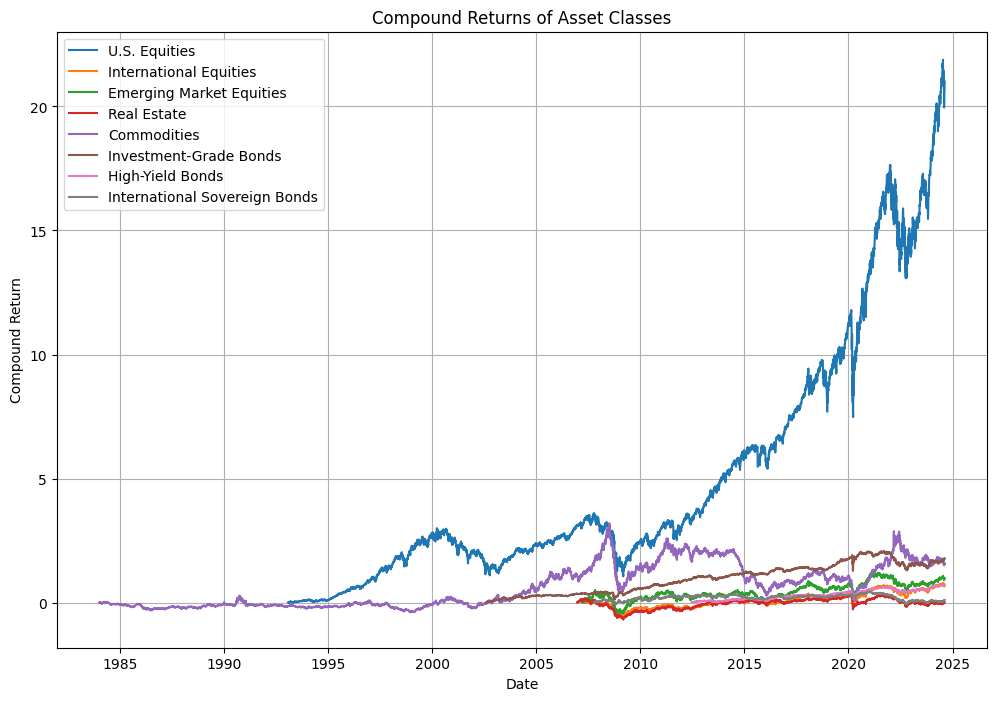

In [4]:
# Calculate compound returns
compound_returns = (1 + returns_df).cumprod() - 1

# Plot the compound returns
plt.figure(figsize=(12, 8))
for column in compound_returns.columns:
    plt.plot(compound_returns.index, compound_returns[column], label=column)

plt.title('Compound Returns of Asset Classes')
plt.ylabel('Compound Return')
plt.xlabel('Date')
plt.legend()
plt.grid(True)
plt.show()

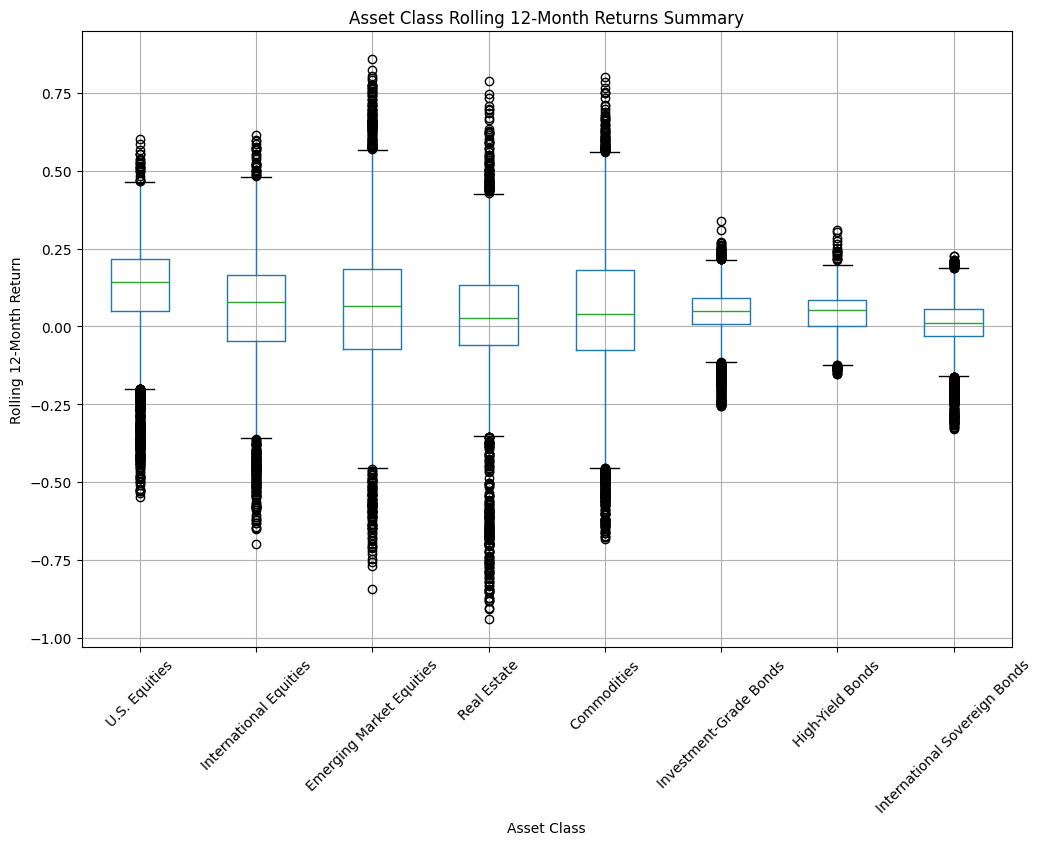

In [5]:
# Calculate 12-month rolling returns
rolling_returns = returns_df.rolling(window=trading_days_in_year).sum()  # 252 trading days in a year

# Plot the box and whisker chart for rolling 12-month returns
plt.figure(figsize=(12, 8))
rolling_returns.boxplot()
plt.title('Asset Class Rolling 12-Month Returns Summary')
plt.ylabel('Rolling 12-Month Return')
plt.xlabel('Asset Class')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

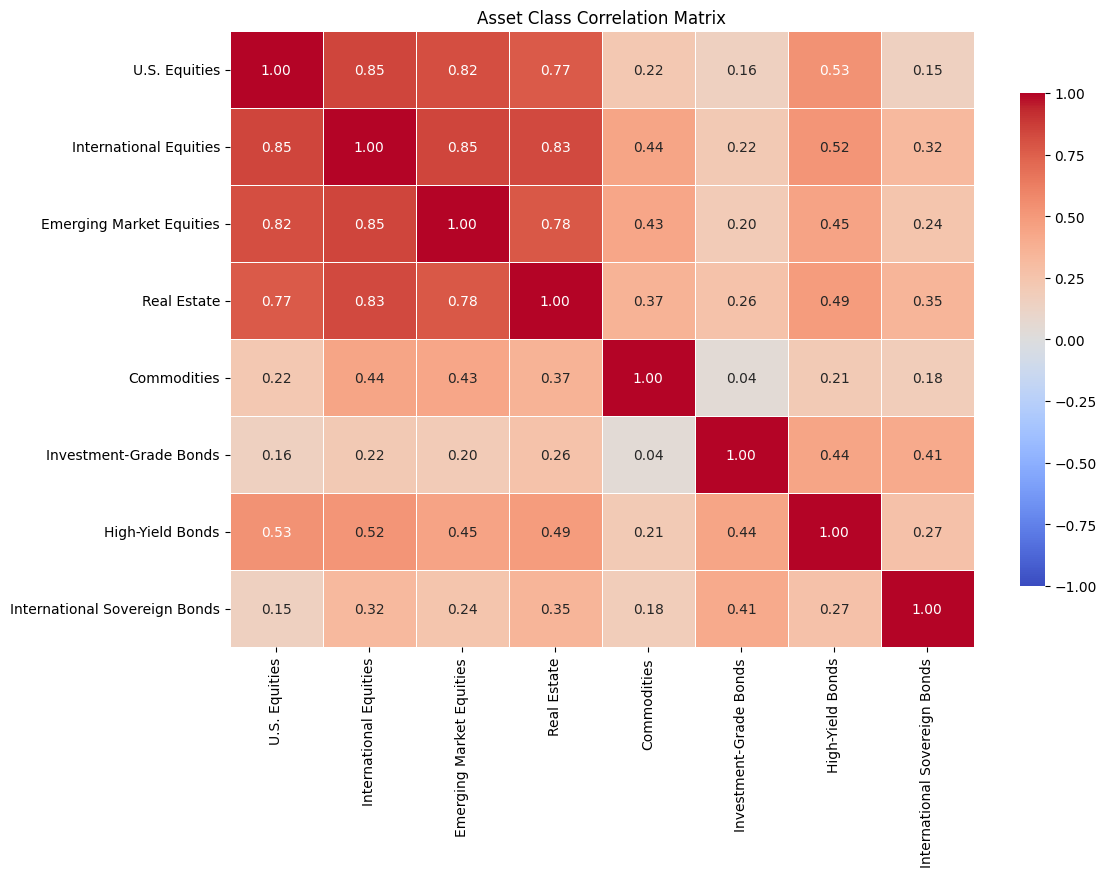

In [6]:
import seaborn as sns

# Calculate the correlation matrix of the daily returns
correlation_matrix = returns_df.corr()

# Plot the correlation matrix using a heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0, 
            linewidths=0.5, fmt='.2f', cbar_kws={"shrink": .8})
plt.title('Asset Class Correlation Matrix')
plt.show()


In [7]:
def plot_rolling_correlations(returns_df, target_asset, comparison_assets, window_months=12, plots_per_row=3):
    """
    Plot the n-month rolling correlations between a target asset class and each comparison asset class in a grid of plots.

    Parameters:
    - returns_df (pd.DataFrame): DataFrame containing daily returns for various asset classes.
    - target_asset (str): The asset class to which correlations are computed.
    - comparison_assets (list of str): List of asset classes to compare against the target asset.
    - window_months (int): Rolling window size in months.
    - plots_per_row (int): Number of plots per row in the grid.
    """
    # Convert window size from months to trading days (approx. 21 trading days per month)
    window_days = window_months * 21
    
    # Determine the number of rows needed
    num_plots = len(comparison_assets)
    num_rows = int(np.ceil(num_plots / plots_per_row))
    
    plt.figure(figsize=(plots_per_row * 5, num_rows * 4))  # Adjust size for grid layout

    for i, asset in enumerate(comparison_assets):
        if asset in returns_df.columns:
            # Calculate rolling correlation with the target asset
            rolling_corr = returns_df[asset].rolling(window=window_days).corr(returns_df[target_asset])
            
            # Determine subplot position
            row = i // plots_per_row
            col = i % plots_per_row
            
            plt.subplot(num_rows, plots_per_row, i + 1)
            plt.plot(rolling_corr.index, rolling_corr, label=asset)
            plt.title(f'{asset}')
            plt.xlabel('Date')
            plt.ylabel('Rolling Correlation')
            plt.legend(loc='best')
            plt.grid(True)
        else:
            print(f"Warning: {asset} not found in returns_df")
    
    plt.tight_layout()  # Adjust layout to prevent overlap
    plt.suptitle(f'{window_months}-Month Rolling Correlations with {target_asset}', y=1.02)
    plt.show()
import numpy as np
target_asset = 'Technology'  # Replace with your target asset class
comparison_assets = returns_df.columns  # Replace with your list of comparison asset classes
plot_rolling_correlations(returns_df, target_asset, comparison_assets, window_months=36)


KeyError: 'Technology'

<Figure size 1500x1200 with 0 Axes>

We start by constructing two-asset portfolios consisting of U.S. equities and investment-grade bonds, experimenting with different equity/bond mixes. These portfolios will show us the increemental effect of adding and removing an asset class in a portfolio

In [ ]:
equities, bonds = "U.S. Equities", "Investment-Grade Bonds"

# Define portfolio weights
weights = np.arange(0, 1.1, 0.1)  # 0%, 10%, 20%, ..., 100%

# Initialize lists to store performance metrics
annualized_returns = []
annualized_risks = []
return_per_risk_ratios = []

# Calculate performance metrics for each portfolio
for weight in weights:
    # Define portfolio weights
    w_equities = weight
    w_bonds = 1 - weight
    
    # Portfolio returns and risk
    portfolio_returns = returns_df[equities] * w_equities + returns_df[bonds] * w_bonds
    annualized_return = (1 + portfolio_returns.mean()) ** trading_days_in_year - 1
    annualized_risk = portfolio_returns.std() * np.sqrt(trading_days_in_year)
    
    # Return-per-unit-of-risk ratio
    return_per_risk_ratio = annualized_return / annualized_risk if annualized_risk != 0 else np.nan
    
    # Store results
    annualized_returns.append(annualized_return)
    annualized_risks.append(annualized_risk)
    return_per_risk_ratios.append(return_per_risk_ratio)

# Create DataFrame for plotting
results_df = pd.DataFrame({
    'Weight U.S. Equities': weights,
    'Annualized Return': annualized_returns,
    'Annualized Risk': annualized_risks,
    'Return per Unit of Risk': return_per_risk_ratios
})

results_df.head(20)

In [ ]:
# Scatter plot of annualized risk vs. annualized return
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.scatter(results_df['Annualized Risk'], results_df['Annualized Return'], c=weights, cmap='viridis', s=100)
plt.colorbar(label='Weight of U.S. Equities')
plt.title('Annualized Risk vs. Annualized Return')
plt.xlabel('Annualized Risk')
plt.ylabel('Annualized Return')
plt.grid(True)

In [ ]:
# Set up the figure and axis
plt.figure(figsize=(12, 6))

# Create a bar plot with improved aesthetics
sns.barplot(x=results_df['Weight U.S. Equities'], 
            y=results_df['Return per Unit of Risk'],
            palette='viridis',  # Color palette
            edgecolor='black')  # Add edge color for bars

# Add annotations for each bar
for i, value in enumerate(results_df['Return per Unit of Risk']):
    plt.text(i, value, f'{value:.2f}', ha='center', va='bottom', fontsize=10, color='black')

# Customize plot
plt.title('Return per Unit of Risk for Various Asset Allocations', fontsize=16, fontweight='bold')
plt.xlabel('Weight of U.S. Equities', fontsize=14)
plt.ylabel('Return per Unit of Risk', fontsize=14)
plt.xticks(ticks=range(len(results_df['Weight U.S. Equities'])), labels=[f'{int(w*100)}%' for w in results_df['Weight U.S. Equities']])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Show plot
plt.show()

In [ ]:
two_asset_returns = returns_df[[equities, bonds]]
annual_mean_returns = two_asset_returns.mean() * trading_days_in_year
annual_cov_matrix = two_asset_returns.cov() * trading_days_in_year

# Annualize standard deviations
annual_std = two_asset_returns.std() * np.sqrt(trading_days_in_year)

# Display annualized metrics
print("Annualized Mean Returns:\n")
print(annual_mean_returns)
print("\nAnnualized Standard Deviations:")
print(annual_std)
print("\nAnnualized Covariance Matrix:")
annual_cov_matrix

In [ ]:
def mean_variance_optimizer(returns_df, rf_rate=0, num_portfolios=10000):
    """
    Perform mean-variance optimization for a given list of asset tickers.

    Parameters:
    - tickers (list): List of asset tickers.
    - start_date (str): Start date for historical data in 'YYYY-MM-DD' format.
    - end_date (str): End date for historical data in 'YYYY-MM-DD' format.
    - rf_rate (float): Risk-free rate (default is 0).
    - num_portfolios (int): Number of random portfolios to generate (default is 10,000).

    Returns:
    - results_df (pd.DataFrame): DataFrame containing portfolio performance metrics.
    - weights_df (pd.DataFrame): DataFrame containing portfolio weights.
    - max_sharpe_portfolio (pd.Series): Weights of the portfolio with the maximum Sharpe ratio.
    - min_volatility_portfolio (pd.Series): Weights of the portfolio with the minimum volatility.
    """
    tickers = returns_df.columns
    annual_mean_returns = returns_df.mean() * trading_days_in_year
    annual_cov_matrix = returns_df.cov() * trading_days_in_year

    # Define portfolio performance
    def portfolio_performance(weights, mean_returns, cov_matrix, rf_rate):
        returns = np.dot(weights, mean_returns)
        std = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
        sharpe_ratio = (returns - rf_rate) / std
        return returns, std, sharpe_ratio

    # Generate random portfolios
    results = np.zeros((4, num_portfolios))
    weights_record = []

    for i in range(num_portfolios):
        weights = np.random.random(returns_df.shape[1])
        weights /= np.sum(weights)
        weights_record.append(weights)

        portfolio_return, portfolio_std, portfolio_sharpe = portfolio_performance(weights, annual_mean_returns, annual_cov_matrix, rf_rate)

        results[0, i] = portfolio_return
        results[1, i] = portfolio_std
        results[2, i] = portfolio_sharpe
        results[3, i] = portfolio_return / portfolio_std  # Return per unit of risk

    # Convert results array to DataFrame
    results_df = pd.DataFrame(results.T, columns=['Return', 'Volatility', 'Sharpe Ratio', 'Return per Unit of Risk'])
    weights_df = pd.DataFrame(weights_record, columns=returns_df.columns)

    # Identify the optimal portfolios
    max_sharpe_idx = results_df['Sharpe Ratio'].idxmax()
    min_volatility_idx = results_df['Volatility'].idxmin()

    max_sharpe_portfolio = weights_df.iloc[max_sharpe_idx]
    min_volatility_portfolio = weights_df.iloc[min_volatility_idx]
    
    return results_df, weights_df, max_sharpe_portfolio, min_volatility_portfolio

results_df, weights_df, max_sharpe_portfolio, min_volatility_portfolio = mean_variance_optimizer(two_asset_returns)

In [ ]:
results_df.head()

In [ ]:
weights_df.head()

In [ ]:
max_sharpe_portfolio

In [ ]:
min_volatility_portfolio

In [ ]:
def plot_optimization_results(results_df, weights_df, tickers, max_sharpe_portfolio, min_volatility_portfolio):
    """
    Plot the efficient frontier and the optimal portfolios with pie charts.

    Parameters:
    - results_df (pd.DataFrame): DataFrame containing portfolio performance metrics.
    - weights_df (pd.DataFrame): DataFrame containing portfolio weights.
    - tickers (list): List of asset tickers.
    - max_sharpe_portfolio (pd.Series): Weights of the portfolio with the maximum Sharpe ratio.
    - min_volatility_portfolio (pd.Series): Weights of the portfolio with the minimum volatility.
    """
    # Plot Efficient Frontier
    plt.figure(figsize=(14, 8))
    
    # Scatter plot of all portfolios
    scatter = plt.scatter(results_df['Volatility'], results_df['Return'], 
                          c=results_df['Sharpe Ratio'], cmap='viridis', 
                          marker='o', s=50, alpha=0.6, edgecolors='w', linewidth=0.5)
    
    # Color bar
    cbar = plt.colorbar(scatter)
    cbar.set_label('Sharpe Ratio', fontsize=12)
    
    
    # Highlight the optimal portfolios
    plt.scatter(results_df.loc[results_df['Sharpe Ratio'].idxmax(), 'Volatility'], 
                results_df.loc[results_df['Sharpe Ratio'].idxmax(), 'Return'], 
                marker='*', color='r', s=300, label='Max Sharpe Ratio', edgecolor='black')
    plt.scatter(results_df.loc[results_df['Volatility'].idxmin(), 'Volatility'], 
                results_df.loc[results_df['Volatility'].idxmin(), 'Return'], 
                marker='*', color='b', s=300, label='Min Volatility', edgecolor='black')

    # Titles and labels
    plt.title('Efficient Frontier with Portfolio Optimization', fontsize=16)
    plt.xlabel('Annualized Volatility', fontsize=14)
    plt.ylabel('Annualized Return', fontsize=14)
    
    # Grid and legend
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(fontsize=12)
    
    plt.show()

    # Plot Asset Allocation of Optimal Portfolios as Pie Charts
    fig, ax = plt.subplots(1, 2, figsize=(14, 6))
    
    # Max Sharpe Ratio Portfolio
    ax[0].pie(max_sharpe_portfolio, labels=tickers, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('viridis', len(tickers)))
    ax[0].set_title('Max Sharpe Ratio Portfolio', fontsize=14)

    # Min Volatility Portfolio
    ax[1].pie(min_volatility_portfolio, labels=tickers, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('viridis', len(tickers)))
    ax[1].set_title('Min Volatility Portfolio', fontsize=14)

    plt.tight_layout()
    plt.show()

plot_optimization_results(results_df, weights_df, tickers=list(two_asset_returns.columns), max_sharpe_portfolio=max_sharpe_portfolio, min_volatility_portfolio=min_volatility_portfolio)

Above proves Two Mutual Theorem. Let's include more asset classes

In [ ]:
results_df, weights_df, max_sharpe_portfolio, min_volatility_portfolio = mean_variance_optimizer(returns_df)
plot_optimization_results(results_df, weights_df, tickers=list(returns_df.columns), 
                          max_sharpe_portfolio=max_sharpe_portfolio, min_volatility_portfolio=min_volatility_portfolio,
                         )

Now let's compare performance of an equal contribution portfolio against a mean-variance optimized one, rebalancing on a quarterly basis

In [ ]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# Define the function for downloading the data
def download_data(tickers, start_date, end_date):
    data = yf.download(tickers, start=start_date, end=end_date)['Adj Close']
    return data


from scipy.optimize import minimize
import numpy as np
import pandas as pd

annualized_factor_from_freq = {"daily": 252, "monthly": 12, "quarterly": 4, "yearly": 1}


def get_valid_assets(returns):
    # Remove columns where all values are NaN
    non_nan_assets = returns.dropna(axis=1, how='all')
    
    # Remove columns where all remaining values are 0
    cleaned_ret = non_nan_assets.loc[:, (non_nan_assets != 0).any()]
    
    # Return list of valid asset names
    return list(cleaned_ret.columns)
    
def equal_contribution_weights(returns):
    assets = get_valid_assets(returns=returns)
    num_assets = len(assets)
    
    # Create a Series with equal weights for valid assets only
    weights = pd.Series(1. / num_assets, index=assets)
    
    # Ensure that all columns are represented, including non-valid assets with weight 0
    full_weights = pd.Series(0., index=returns.columns)
    full_weights[assets] = weights
    
    return full_weights


# Define the function for calculating annualized return and volatility
# def annualized_performance(returns, frequency):
#     annual_factor = annualized_factor_from_freq[frequency]
#     mean_returns = returns.mean() * annual_factor
#     vol_returns = returns.std() * np.sqrt(annual_factor)
#     return mean_returns, vol_returns

def annualized_expected_return(returns, frequency="daily"):
    assert frequency in annualized_factor_from_freq
    annual_factor = annualized_factor_from_freq[frequency]
    ann_return = (1 + returns.mean()) ** annual_factor - 1
    return ann_return

def annualized_volatility(returns, frequency="daily"):
    assert frequency in annualized_factor_from_freq
    annual_factor = annualized_factor_from_freq[frequency]
    ann_vol = returns.std() * np.sqrt(annual_factor)
    return ann_vol

def portfolio_return_from_weights(weights, mean_returns):
    return np.dot(weights, mean_returns)

def portfolio_volatility_from_weights(weights, cov_matrix):
    return np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))

def sharpe_ratio(expected_return, volatility_return, risk_free_rate=0.01):
    return (expected_return - risk_free_rate) / volatility_return

def get_valid_assets(returns):
    # Remove columns where all values are NaN
    non_nan_assets = returns.dropna(axis=1, how='all')
    
    # Remove columns where all remaining values are 0
    cleaned_ret = non_nan_assets.loc[:, (non_nan_assets != 0).any()]
    
    # Return list of valid asset names
    return list(cleaned_ret.columns)

def portfolio_optimization(returns, frequency, goal='minVol', risk_free_rate=0.01):
    annual_factor = annualized_factor_from_freq[frequency]
    
    # Get mean returns and covariance matrix up to the given date
    mean_returns = annualized_expected_return(returns=returns)
    cov_matrix = returns.cov() * annual_factor

    # Identify valid assets (non-NaN or non-zero returns)
    valid_assets = get_valid_assets(returns=returns)
    num_assets = len(valid_assets)
    # print("Valid Assets:", valid_assets)
    # If there are no valid assets left after cleaning
    if not num_assets:
        return pd.Series(index=mean_returns.index, dtype=float).fillna(0)

    # Filter returns and covariance matrix to include only valid assets
    mean_returns_filtered = mean_returns[valid_assets]
    cov_matrix_filtered = cov_matrix.loc[valid_assets, valid_assets]
    
    # Constraints and bounds for the optimization
    constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
    bounds = tuple((0, 1) for _ in range(num_assets))
    initial_guess = num_assets * [1. / num_assets]

    if goal == "minVol":
        f = lambda w: portfolio_volatility_from_weights(weights=w, cov_matrix=cov_matrix_filtered)
    elif goal == 'maxSharpe':
        f = lambda w: -sharpe_ratio(
            expected_return=portfolio_return_from_weights(weights=w, mean_returns=mean_returns_filtered),
            volatility_return=portfolio_volatility_from_weights(weights=w, cov_matrix=cov_matrix_filtered),
            risk_free_rate=risk_free_rate
        )
    else:
        raise ValueError("Invalid goal specified. Use 'minVol' or 'maxSharpe'.")

    result = minimize(f, initial_guess, method='SLSQP', bounds=bounds, constraints=constraints)

    if result.success:
        optimized_weights = pd.Series(result.x, index=valid_assets)
    else:
        raise ValueError("Optimization did not converge")
    
    # Assign weights for valid assets
    final_weights = pd.Series(index=mean_returns.index, dtype=float).fillna(0)
    final_weights.loc[valid_assets] = optimized_weights
    
    return final_weights

def calculate_portfolio_return(weights, returns):
    return np.dot(weights.fillna(0), returns.fillna(0))

def compute_weighted_returns(weights, returns):
    # Function to calculate portfolio return for a given date
    def calc_portfolio_return(date):
        weights = stored_weights_filled.loc[date]
        returns_today = returns.loc[date]
        portfolio_return = calculate_portfolio_return(weights, returns_today)
        return portfolio_return
        
    # Map the function to calculate portfolio returns
    portfolio_returns = returns.index.to_series().map(calc_portfolio_return)
    # Convert portfolio_returns to a Series with the same index
    portfolio_returns = pd.Series(portfolio_returns.values, index=returns.index)
    return portfolio_returns

def portfolio_allocation(returns, 
                          method='minVol', # 'eqCont', 'maxSharpe'
                          rebalance_freq='Q', 
                          frequency='daily', 
                          risk_free_rate=0.01):
    # rebalanace freq: M, Q, A for monthly, quarterly, and annualy
    # Create DataFrames for storing results
    stored_weights = pd.DataFrame(index=returns.index, columns=returns.columns)
    portfolio_returns = pd.Series(index=returns.index)
    assert frequency in annualized_factor_from_freq
    
    # Function to compute weights for a given date
    def compute_weights(date):

        try:
            if method == 'minVol':
                weights = portfolio_optimization(returns=returns.loc[:date], frequency=frequency, goal=method)
            elif method == 'eqCont':
                weights = equal_contribution_weights(returns=returns.loc[:date])
            elif method == 'maxSharpe':
                weights = portfolio_optimization(returns=returns.loc[:date], frequency=frequency, goal=method)
            # print("Date", date)
            # print("Weights:", weights)
            stored_weights.loc[date] = weights
        except ValueError as e:
            print(f"Error in optimization for date {date}: {e}")
            stored_weights.loc[date] = pd.Series(np.nan, index=returns.columns)
    
    # Compute weights for all rebalance dates
    rebalance_dates = returns.index.to_series().to_period(rebalance_freq).to_timestamp(rebalance_freq).sort_index().index.drop_duplicates()
    # print("Rebalance Dates:", rebalance_dates)
    rebalance_dates.map(compute_weights)

    # Shift weights to align with future returns and forward fill
    stored_weights_shifted = stored_weights.shift(1)
    stored_weights_filled = stored_weights_shifted.ffill().fillna(0)
    # print(f"Stored Weights:\n{stored_weights}")
    # print(f"Stored Weights Shifted:\n{stored_weights_shifted}")
    # print(f"Stored Weights Filled:\n{stored_weights_filled.iloc}")
    portfolio_returns = compute_weighted_returns(weights=stored_weights_filled, returns=returns)
    return portfolio_returns

import pandas as pd

def portfolio_performance(portfolio_returns: pd.Series, frequency: str = "daily", risk_free_rate: float = 0.01):
    # Calculate cumulative portfolio returns
    portfolio_returns_cum = (1 + portfolio_returns).cumprod() - 1
    
    # Calculate annualized expected return
    optimized_ann_return = annualized_expected_return(returns=portfolio_returns, frequency=frequency)
    
    # Calculate annualized volatility
    optimized_vol = annualized_volatility(returns=portfolio_returns, frequency=frequency)
    
    # Calculate Sharpe Ratio
    optimized_sharpe = sharpe_ratio(expected_return=optimized_ann_return, 
                                    volatility_return=optimized_vol, 
                                    risk_free_rate=risk_free_rate)
    
    # Return a dictionary with all calculated values
    performance_metrics = {
        "cumulative_returns": portfolio_returns_cum,
        "annualized_return": optimized_ann_return,
        "annualized_volatility": optimized_vol,
        "sharpe_ratio": optimized_sharpe,
        "portfolio_returns": portfolio_returns
    }
    
    return performance_metrics

# Define the plotting function
def plot_portfolio_performance(portfolio_cum, sharpe):
    plt.figure(figsize=(14, 8))
    # plt.plot(equal_contrib_portfolio_cum, label=f'Equal Contribution Portfolio (Sharpe: {equal_contrib_sharpe:.2f})', linewidth=2)
    plt.plot(portfolio_cum, label=f'Mean-Variance Optimized Portfolio (Sharpe: {sharpe:.2f})', linewidth=2)
    plt.title('Portfolio Performance Comparison')
    plt.xlabel('Date')
    plt.ylabel('Cumulative Return')
    plt.legend()
    plt.grid(True)
    plt.show()

# start_date = "2010-01-01"
# end_date = "2023-12-31"

# # Calculate portfolio performance
#  optimized_vol, optimized_sharpe = portfolio_performance(data, tickers)
monthly_returns_df = (1 + returns_df).resample('ME').prod() - 1
portfolio_returns = portfolio_allocation(returns_df, frequency='daily', method='eqCont')
# portfolio_returns = portfolio_allocation(returns_df, frequency='daily', method='minVol')
# portfolio_returns = portfolio_allocation(returns_df, frequency='daily', method='maxSharpe')

post_processing = portfolio_performance(portfolio_returns=portfolio_returns, frequency="daily")
# Plot the performance
plot_portfolio_performance(portfolio_cum=post_processing["cumulative_returns"], sharpe=post_processing["sharpe_ratio"])

In [ ]:
portfolio_returns_cum

In [ ]:
optimized_sharpe